# Multivariate Regression Epidemics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [4]:
import json
from pathlib import Path

# path to the JSON file
json_path = Path("..") / "Data" / "gold" / "features_dict.json"

# read it into a Python dict
with json_path.open("r", encoding="utf‑8") as f:
    features_dict = json.load(f)

# quick sanity check
print(f"Loaded {len(features_dict)} keys from features_dict.json")

Loaded 2 keys from features_dict.json


In [5]:
selected_features_epidemics = features_dict['dengue']
selected_features_epidemics

['dengue', 'pres', 'google_symptom', 'date_num', 'pm25']

In [6]:
selected_features_epidemics
#selected_features_epidemics.extend(['date', 'zika', 'chik', 'var'])

['dengue', 'pres', 'google_symptom', 'date_num', 'pm25']

# Wrangle

In [7]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [8]:
# drop duplicated  columns
df = df.loc[:, ~df.columns.duplicated()]
df

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2023-11-27,3118,0.0,1.0,459.0,2023-11-27,19.216266,12.896204,25.435018,0.714470,...,6,24,10.857143,10.928571,73.971429,10.464286,5.121429,30.714286,52.785714,0.628571
193,2023-12-04,3369,0.0,1.0,388.0,2023-12-04,19.273944,13.558017,25.321583,1.902538,...,5,26,11.550000,11.392857,75.278571,11.128571,5.564286,32.642857,55.214286,0.628571
194,2023-12-11,3446,1.0,1.0,430.0,2023-12-11,19.493746,14.694348,25.424447,4.540202,...,4,24,12.235714,12.642857,80.657143,12.878571,4.500000,34.357143,63.000000,0.742857
195,2023-12-18,3312,2.0,2.0,344.0,2023-12-18,19.810996,14.662213,25.917042,3.151673,...,5,25,12.050000,13.142857,79.214286,15.557143,6.064286,29.714286,61.642857,0.714286


In [9]:
df.rename(columns={'chik': 'chikungunya', 'var': 'varicella'}, inplace=True)

In [10]:
tarteg_cols = ['dengue', 'zika', 'chikungunya', 'varicella']
for col in tarteg_cols:
    df[col+'_1'] = df[col].shift(-1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              197 non-null    object 
 1   dengue            197 non-null    int64  
 2   zika              197 non-null    float64
 3   chikungunya       197 non-null    float64
 4   varicella         197 non-null    float64
 5   date              197 non-null    object 
 6   tavg              197 non-null    float64
 7   tmin              197 non-null    float64
 8   tmax              197 non-null    float64
 9   prcp              197 non-null    float64
 10  wdir              197 non-null    float64
 11  wspd              197 non-null    float64
 12  pres              197 non-null    float64
 13  mob_index         197 non-null    float64
 14  google_physician  197 non-null    int64  
 15  google_hospital   197 non-null    int64  
 16  google_pharmacy   197 non-null    int64  
 1

In [12]:
# drop nans
df.dropna(subset=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              196 non-null    object 
 1   dengue            196 non-null    int64  
 2   zika              196 non-null    float64
 3   chikungunya       196 non-null    float64
 4   varicella         196 non-null    float64
 5   date              196 non-null    object 
 6   tavg              196 non-null    float64
 7   tmin              196 non-null    float64
 8   tmax              196 non-null    float64
 9   prcp              196 non-null    float64
 10  wdir              196 non-null    float64
 11  wspd              196 non-null    float64
 12  pres              196 non-null    float64
 13  mob_index         196 non-null    float64
 14  google_physician  196 non-null    int64  
 15  google_hospital   196 non-null    int64  
 16  google_pharmacy   196 non-null    int64  
 17  go

In [13]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_num'] = df['date'].apply(lambda x: x.timestamp())

In [14]:
selected_features_epidemics

['dengue', 'pres', 'google_symptom', 'date_num', 'pm25']

In [15]:
selected_features_epidemics.extend(['date', 'zika', 'chikungunya', 'varicella',
                                    'dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1'])

In [16]:
df = df[selected_features_epidemics]

In [17]:
df_og = df.copy()

# Regression Framework

In [18]:
targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']

## OLS

In [19]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error, r2_score
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Copy & drop rows where the current target is NaN
    df_tgt = df.copy()
    df_tgt = df_tgt.dropna(subset=[tgt]).sort_values('date').reset_index(drop=True)

    if len(df_tgt) < 20:                # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non‑NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # remove all target cols + date
         .select_dtypes(include='number'))        # numeric predictors only
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics
    

    # ---- 1.3  Time‑series split: last fold is hold‑out
    # outer_split = TimeSeriesSplit(n_splits=5)
    # train_idx, test_idx = list(outer_split.split(X))[-1]
    # ---- 2.3  Custom 80-20 chronological split
    split_point = int(len(X) * 0.8)          # 80 % train, 20 % test

    train_idx = np.arange(split_point)
    test_idx  = np.arange(split_point, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Fit OLS
    ols = LinearRegression()
    ols.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = ols.predict(X_test)
    y_pred_train = ols.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test) for this target
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (date index, target columns)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid (one panel per target)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

# Hide any unused subplot (if fewer than 4 targets were modelled)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/OLS_epidemics.csv', index = True)

## Lasso

In [ ]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV

df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row


# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                            # too few points?
        print(f"[{tgt}] skipped (only {len(df_tgt)} non‑NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])          # drop ALL target cols + date
         .select_dtypes(include='number'))          # numeric predictors
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: scaler → LassoCV
    #           inner CV keeps order (3 folds on TRAIN only)
    inner_cv = TimeSeriesSplit(n_splits=3)

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LassoCV(cv=inner_cv,
                           random_state=42,
                           n_alphas=50,
                           max_iter=5000))
    ])

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/Lasso_epidemics.csv', index = True)

## Ridge

In [ ]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                            # too few points?
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])          # drop ALL target cols + date
         .select_dtypes(include='number'))          # numeric predictors
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ RidgeCV
    inner_cv   = TimeSeriesSplit(n_splits=3)   # CV folds on TRAIN only
    ridge_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           scoring='neg_root_mean_squared_error'))
    ])

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

# Hide unused panels (if any)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/Ridge_epidemics.csv', index = True)

## ElasticNet

In [ ]:

from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])
         .select_dtypes(include='number'))
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ ElasticNetCV (l1_ratio = 0.5)
    inner_cv = TimeSeriesSplit(n_splits=3) # CV on TRAIN only
    enet_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(
                      l1_ratio     = 0.5,                      # 50-50 mix
                      alphas       = np.logspace(-3, 3, 30),
                      cv           = inner_cv,
                      random_state = 42,
                      max_iter     = 5000))
    ])

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/ElasticNet_epidemics.csv', index = True)

## Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble        import RandomForestRegressor
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row
# -------------------------------------------------------------
# 1.  Hyper-parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                          # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # drop ALL targets + date
         .select_dtypes(include='number'))        # numeric predictors only
    
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']


    # ---- 2.4  Inner CV: grid-search random forest on training part
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "best_params": best_params})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/RF_epidemics.csv', index = True)

## Gradient Boosting

In [ ]:
from sklearn.ensemble        import GradientBoostingRegressor
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper-parameter grid  (coarse → refine once you see winners)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [200, 400, 800],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.7, 0.9, 1.0],
    "min_samples_leaf": [1, 3, 5],
    "max_features":     ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                          # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # drop ALL target cols + date
         .select_dtypes(include='number'))        # numeric predictors only
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 1.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']


    # ---- 2.4  Inner CV: grid-search GBM on training portion
    inner_cv = TimeSeriesSplit(n_splits=3)
    gb_base  = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator   = gb_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "best_params": best_params})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/GB_epidemics.csv', index = True)

## SVM

In [ ]:
from sklearn.svm            import SVR
df = df_og.copy()

In [ ]:



# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']
targets_lagged = {'dengue_1':'dengue',
                  'zika_1':'zika',
                  'chikungunya_1':'chikungunya',
                  'varicella_1':'varicella'}
targets_lagged_list = list(targets_lagged.values())

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper-parameter grid for an RBF-kernel SVR
# -------------------------------------------------------------
param_grid = [
    {   # RBF search
        "model__kernel":  ["rbf"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
        "model__gamma":   ["scale", 0.01, 0.1, 1.0],
    },
    {   # Linear search (no gamma)
        "model__kernel":  ["linear"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
    },
]

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (
        df.dropna(subset=[tgt])
          .sort_values('date')
          .reset_index(drop=True)
    )

    if len(df_tgt) < 20:
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (
        df_tgt
        .drop(columns=targets + ['date'])     # remove ALL target cols + date
        .select_dtypes(include='number')      # numeric predictors only
    )
    # drop epidemics that are not same as target
    targets_lagged_remove = targets_lagged_list.copy() # get a list of epidemics
    targets_lagged_remove.remove(targets_lagged[tgt]) # dont remove target epidemic (lagged)
    X = X.drop(columns=targets_lagged_remove) # remove other lagged epidemics

    
    # ---- 2.3 Chronological 80 / 20 split---------------
    split_pt = int(len(X) * 0.8)          # 80 % train, 20 % test
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(X))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']



    # ---- 2.4  Pipeline: StandardScaler ➜ SVR + grid search
    inner_cv = TimeSeriesSplit(n_splits=3)

    svr_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model",  SVR())
        ]
    )

    grid = GridSearchCV(
        estimator   = svr_pipe,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0,
    )
    grid.fit(X_train, y_train)

    best_svr    = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "target":     tgt,
        "rmse":       rmse,
        "r2":         r2,
        "best_params": best_params
    })

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/SVM_epidemics.csv', index = True)

They depend almost exclusively on their lagged variables, so modelling as VAR is a good Idea / or any other time series approach as has been done until now

# Coefficients - Dengue

## OLS

In [46]:
from sklearn.linear_model import LinearRegression

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1.  Prepare dengue-only dataset
# -------------------------------------------------------------
df_d = (
    df
    .dropna(subset=['dengue_1'])              # keep only rows with dengue data
    .sort_values('date')                      # chronological order
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2.  Split features / target
# -------------------------------------------------------------
y = df_d['dengue_1']
X = (
    df_d
    .drop(columns=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1', 'date', 'zika', 'chikungunya', 'varicella'])  # drop ALL target cols + date
    .select_dtypes(include='number')
)

# -------------------------------------------------------------
# 3.  Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt   = int(0.80 * len(X))
X_train    = X.iloc[:split_pt]
X_test     = X.iloc[split_pt:]
y_train    = y.iloc[:split_pt]
y_test     = y.iloc[split_pt:]

# -------------------------------------------------------------
# 4.  Fit Linear Regression
# -------------------------------------------------------------
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# -------------------------------------------------------------
# 5.  Extract coefs + intercept into a Series
# -------------------------------------------------------------
β = linreg.coef_           # array of feature coefficients
b = linreg.intercept_      # intercept (scalar)
feature_names = X_train.columns.tolist()

coef_series = pd.Series(
    data    = np.concatenate([[b], β]),
    index   = ["intercept"] + feature_names,
    name    = "dengue_1"
)

print("Dengue OLS coefficients (intercept first):")
print(coef_series)

Dengue OLS coefficients (intercept first):
intercept        -6.508070e+03
dengue            9.323730e-01
pres              5.947872e+00
google_symptom   -2.308818e+00
date_num          3.359457e-07
pm25              3.681199e-01
Name: dengue_1, dtype: float64


In [47]:
import statsmodels.api as sm

# 1. Add a constant column for the intercept
X_train_const = sm.add_constant(X_train)  # adds a “const” column of 1s

# 2. Fit the OLS on your training data
ols_sm = sm.OLS(y_train, X_train_const).fit()

# 3. Print the full regression table
print(ols_sm.summary())

                            OLS Regression Results                            
Dep. Variable:               dengue_1   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     695.6
Date:                Tue, 17 Jun 2025   Prob (F-statistic):          8.01e-102
Time:                        20:02:57   Log-Likelihood:                -896.08
No. Observations:                 156   AIC:                             1804.
Df Residuals:                     150   BIC:                             1822.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -6508.0696   3612.868     -1.

In [48]:
# 1. Build a DataFrame of the stats you care about
results_df = pd.DataFrame({
    
    "p_val"  : ols_sm.pvalues
})

# 2. (Optional) Round to 4 decimals or however many you like
results_df = results_df.round(4)

# 3. Export to LaTeX
latex_table = results_df.to_latex(
    caption="OLS parameter estimates",
    label="tab:ols_pvalues_covid",
    float_format="%.4f"
)
print(latex_table)

\begin{table}
\caption{OLS parameter estimates}
\label{tab:ols_pvalues_covid}
\begin{tabular}{lr}
\toprule
 & p_val \\
\midrule
const & 0.0737 \\
dengue & 0.0000 \\
pres & 0.1403 \\
google_symptom & 0.0616 \\
date_num & 0.4757 \\
pm25 & 0.5747 \\
\bottomrule
\end{tabular}
\end{table}



## Lasso

In [50]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression  # if you want to compare later

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1.  Prepare dengue-only dataset
# -------------------------------------------------------------
df_d = (
    df
    .dropna(subset=['dengue_1'])
    .sort_values('date')
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2.  Split features / target
# -------------------------------------------------------------
y = df_d['dengue_1']
X = (
    df_d
    .drop(columns=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1', 'date',  'zika', 'chikungunya', 'varicella'])
    .select_dtypes(include='number')
)

# -------------------------------------------------------------
# 3.  Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_pt], X.iloc[split_pt:]
y_train, y_test = y.iloc[:split_pt], y.iloc[split_pt:]

# -------------------------------------------------------------
# 4.  Pipeline: scaler → LassoCV with time-series CV
# -------------------------------------------------------------
inner_cv = TimeSeriesSplit(n_splits=3)
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LassoCV(cv=inner_cv,
                       random_state=42,
                       n_alphas=50,
                       max_iter=5000))
])
lasso_pipe.fit(X_train, y_train)

# -------------------------------------------------------------
# 5.  Extract best model + coefficients
# -------------------------------------------------------------
lasso = lasso_pipe.named_steps["model"]
best_alpha = lasso.alpha_
β = lasso.coef_        # array of feature coefficients
b = lasso.intercept_   # intercept

# -------------------------------------------------------------
# 6.  Build a Series (intercept first) named coef_series_lasso
# -------------------------------------------------------------
feature_names = X_train.columns.tolist()
coef_series_lasso = pd.Series(
    data    = np.concatenate([[b], β]),
    index   = ["intercept"] + feature_names,
    name    = "dengue_1_lasso"
)

print(f"Best α (alpha): {best_alpha}")
print("Dengue Lasso coefficients (intercept first):")
print(coef_series_lasso)

Best α (alpha): 4.593362524140581
Dengue Lasso coefficients (intercept first):
intercept         754.173077
dengue            342.588127
pres               10.933205
google_symptom     -9.175788
date_num           11.100972
pm25                0.257522
Name: dengue_1_lasso, dtype: float64


In [52]:
# 1. Extract scaler and fitted LassoCV model
scaler_lasso = lasso_pipe.named_steps["scaler"]
model_lasso  = lasso_pipe.named_steps["model"]

# 2. Get the scaled‐space coefficients + intercept
beta_scaled_lasso       = model_lasso.coef_        # shape: (n_features,)
intercept_scaled_lasso  = model_lasso.intercept_   # scalar

# 3. Grab scaler parameters
means_lasso  = scaler_lasso.mean_   # shape: (n_features,)
scales_lasso = scaler_lasso.scale_  # shape: (n_features,)

# 4. Un-scale the feature coefficients
beta_orig_lasso = beta_scaled_lasso / scales_lasso

# 5. Compute the original-scale intercept
intercept_orig_lasso = (
    intercept_scaled_lasso
    - np.dot(beta_scaled_lasso, means_lasso / scales_lasso)
)

# 6A. As a NumPy array (intercept first)
coefs_with_intercept_lasso_orig = np.concatenate(
    [[intercept_orig_lasso], beta_orig_lasso]
)
print("Lasso (original scale) – intercept first:", coefs_with_intercept_lasso_orig)

# 6B. As a pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_lasso_orig = pd.Series(
    data=coefs_with_intercept_lasso_orig,
    index=["intercept"] + feature_names,
    name="lasso_orig_scale"
)
coefs_series_lasso_orig

Lasso (original scale) – intercept first: [-5.16889832e+03  9.26320768e-01  4.52395683e+00 -1.68079651e+00
  4.07590606e-07  2.56553690e-02]


intercept        -5.168898e+03
dengue            9.263208e-01
pres              4.523957e+00
google_symptom   -1.680797e+00
date_num          4.075906e-07
pm25              2.565537e-02
Name: lasso_orig_scale, dtype: float64

## Ridge

In [53]:

from sklearn.linear_model import RidgeCV


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1.  Prepare dengue-only dataset
# -------------------------------------------------------------
df_d = (
    df
    .dropna(subset=['dengue_1'])
    .sort_values('date')
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2.  Split features / target
# -------------------------------------------------------------
y = df_d['dengue_1']
X = (
    df_d
    .drop(columns=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1', 'date', 'zika', 'chikungunya', 'varicella'])  # drop ALL target cols + date
    .select_dtypes(include='number')
)

# -------------------------------------------------------------
# 3.  Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_pt], X.iloc[split_pt:]
y_train, y_test = y.iloc[:split_pt], y.iloc[split_pt:]

# -------------------------------------------------------------
# 4.  Pipeline: StandardScaler → RidgeCV with time-series CV
# -------------------------------------------------------------
ts_cv = TimeSeriesSplit(n_splits=3)
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RidgeCV(
        alphas=np.logspace(-3, 3, 30),
        cv=ts_cv,
        scoring='neg_root_mean_squared_error'
    ))
])
ridge_pipe.fit(X_train, y_train)

# -------------------------------------------------------------
# 5.  Extract best alpha + coefficients
# -------------------------------------------------------------
ridge = ridge_pipe.named_steps["model"]
best_alpha = ridge.alpha_
β = ridge.coef_         # array of feature coefficients
b = ridge.intercept_    # intercept

# -------------------------------------------------------------
# 6.  Build a Series (intercept first) named coef_series_ridge
# -------------------------------------------------------------
feature_names = X_train.columns.tolist()
coef_series_ridge = pd.Series(
    data    = np.concatenate([[b], β]),
    index   = ["intercept"] + feature_names,
    name    = "dengue_1_ridge"
)

print(f"Best α (alpha): {best_alpha}")
print("Dengue Ridge coefficients (intercept first):")
print(coef_series_ridge)


Best α (alpha): 2.0433597178569416
Dengue Ridge coefficients (intercept first):
intercept         754.173077
dengue            335.122580
pres               12.661675
google_symptom    -12.492866
date_num           16.979372
pm25                5.026679
Name: dengue_1_ridge, dtype: float64


In [54]:
# 1. Extract scaler and fitted RidgeCV model
scaler_ridge = ridge_pipe.named_steps["scaler"]
model_ridge  = ridge_pipe.named_steps["model"]

# 2. Get the scaled-space coefficients + intercept
beta_scaled_ridge      = model_ridge.coef_        # shape: (n_features,)
intercept_scaled_ridge = model_ridge.intercept_   # scalar

# 3. Grab scaler parameters
means_ridge  = scaler_ridge.mean_    # shape: (n_features,)
scales_ridge = scaler_ridge.scale_   # shape: (n_features,)

# 4. Un-scale the feature coefficients
beta_orig_ridge = beta_scaled_ridge / scales_ridge

# 5. Compute the original-scale intercept
intercept_orig_ridge = (
    intercept_scaled_ridge
    - np.dot(beta_scaled_ridge, means_ridge / scales_ridge)
)

# 6A. As a NumPy array (intercept first)
coefs_with_intercept_ridge_orig = np.concatenate(
    [[intercept_orig_ridge], beta_orig_ridge]
)
print("Ridge (original scale) – intercept first:", coefs_with_intercept_ridge_orig)

# 6B. As a pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_ridge_orig = pd.Series(
    data=coefs_with_intercept_ridge_orig,
    index=["intercept"] + feature_names,
    name="ridge_orig_scale"
)
coefs_series_ridge_orig

Ridge (original scale) – intercept first: [-6.24359232e+03  9.06134745e-01  5.23916545e+00 -2.28840989e+00
  6.23425839e-07  5.00777704e-01]


intercept        -6.243592e+03
dengue            9.061347e-01
pres              5.239165e+00
google_symptom   -2.288410e+00
date_num          6.234258e-07
pm25              5.007777e-01
Name: ridge_orig_scale, dtype: float64

## Elastic Net

In [55]:
from sklearn.linear_model import ElasticNetCV

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1.  Prepare dengue-only dataset
# -------------------------------------------------------------
df_d = (
    df
    .dropna(subset=['dengue_1'])
    .sort_values('date')
    .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2.  Split features / target
# -------------------------------------------------------------
y = df_d['dengue_1']
X = (
    df_d
    .drop(columns=['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1', 'date', 'zika', 'chikungunya', 'varicella'])  # drop ALL target cols + date
    .select_dtypes(include='number')
)

# -------------------------------------------------------------
# 3.  Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt = int(0.8 * len(X))
X_train, X_test = X.iloc[:split_pt], X.iloc[split_pt:]
y_train, y_test = y.iloc[:split_pt], y.iloc[split_pt:]

# -------------------------------------------------------------
# 4.  Pipeline: StandardScaler → ElasticNetCV (l1_ratio=0.5)
# -------------------------------------------------------------
ts_cv = TimeSeriesSplit(n_splits=3)
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio     = 0.5,
        alphas       = np.logspace(-3, 3, 30),
        cv           = ts_cv,
        random_state = 42,
        max_iter     = 5000
    ))
])
enet_pipe.fit(X_train, y_train)

# -------------------------------------------------------------
# 5.  Extract best alpha + coefficients
# -------------------------------------------------------------
enet = enet_pipe.named_steps["model"]
best_alpha = enet.alpha_
β = enet.coef_         # array of feature coefficients (on scaled features)
b = enet.intercept_    # intercept (on scaled features)

# -------------------------------------------------------------
# 6.  Build a Series (intercept first) named coef_series_enet
# -------------------------------------------------------------
feature_names = X_train.columns.tolist()
coef_series_enet = pd.Series(
    data  = np.concatenate([[b], β]),
    index = ["intercept"] + feature_names,
    name  = "dengue_1_enet"
)

print(f"Best α (alpha): {best_alpha}")
print("Dengue ElasticNet coefficients (intercept first):")
print(coef_series_enet)

Best α (alpha): 0.04520353656360243
Dengue ElasticNet coefficients (intercept first):
intercept         754.173077
dengue            328.655546
pres               11.808455
google_symptom    -12.468337
date_num           21.812238
pm25                5.919635
Name: dengue_1_enet, dtype: float64


In [56]:
# 1. Extract scaler and fitted ElasticNetCV model
scaler_enet = enet_pipe.named_steps["scaler"]
model_enet  = enet_pipe.named_steps["model"]

# 2. Get the scaled-space coefficients + intercept
beta_scaled_enet      = model_enet.coef_        # shape: (n_features,)
intercept_scaled_enet = model_enet.intercept_   # scalar

# 3. Grab scaler parameters
means_enet  = scaler_enet.mean_    # shape: (n_features,)
scales_enet = scaler_enet.scale_   # shape: (n_features,)

# 4. Un-scale the feature coefficients
beta_orig_enet = beta_scaled_enet / scales_enet

# 5. Compute the original-scale intercept
intercept_orig_enet = (
    intercept_scaled_enet
    - np.dot(beta_scaled_enet, means_enet / scales_enet)
)

# 6A. As a NumPy array (intercept first)
coefs_with_intercept_enet_orig = np.concatenate(
    [[intercept_orig_enet], beta_orig_enet]
)
print("ElasticNet (original scale) – intercept first:", coefs_with_intercept_enet_orig)

# 6B. As a pandas Series with named index
feature_names = X_train.columns.tolist()
coefs_series_enet_orig = pd.Series(
    data=coefs_with_intercept_enet_orig,
    index=["intercept"] + feature_names,
    name="elasticnet_orig_scale"
)
print(coefs_series_enet_orig)

ElasticNet (original scale) – intercept first: [-6.16550603e+03  8.88648594e-01  4.88611899e+00 -2.28391686e+00
  8.00872514e-07  5.89737439e-01]
intercept        -6.165506e+03
dengue            8.886486e-01
pres              4.886119e+00
google_symptom   -2.283917e+00
date_num          8.008725e-07
pm25              5.897374e-01
Name: elasticnet_orig_scale, dtype: float64


## All Coefficients

In [61]:
# join all coefficients into a single DataFrame
coef_df = pd.DataFrame({
    "LinearRegression":       coef_series,
    "Lasso":     coefs_series_lasso_orig,
    "Ridge":     coefs_series_ridge_orig,
    "ElasticNet": coefs_series_enet_orig
}).T
coef_df

,intercept,dengue,pres,google_symptom,date_num,pm25
LinearRegression,-6508.069625,0.932373,5.947872,-2.308818,3.359457e-07,0.368120
Lasso,-5168.898317,0.926321,4.523957,-1.680797,4.075906e-07,0.025655
Ridge,-6243.592318,0.906135,5.239165,-2.288410,6.234258e-07,0.500778
ElasticNet,-6165.506035,0.888649,4.886119,-2.283917,8.008725e-07,0.589737


In [63]:

latex_code = coef_df.to_latex(
    float_format="%.2f",
    caption="Model coefficients",
    label="tab:coef_table_dengue"
)
print(latex_code)

\begin{table}
\caption{Model coefficients}
\label{tab:coef_table_dengue}
\begin{tabular}{lrrrrrr}
\toprule
 & intercept & dengue & pres & google_symptom & date_num & pm25 \\
\midrule
LinearRegression & -6508.07 & 0.93 & 5.95 & -2.31 & 0.00 & 0.37 \\
Lasso & -5168.90 & 0.93 & 4.52 & -1.68 & 0.00 & 0.03 \\
Ridge & -6243.59 & 0.91 & 5.24 & -2.29 & 0.00 & 0.50 \\
ElasticNet & -6165.51 & 0.89 & 4.89 & -2.28 & 0.00 & 0.59 \\
\bottomrule
\end{tabular}
\end{table}



# Feature Importance

## RF

⇨ best params: {'bootstrap': True, 'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 1200}
Test RMSE = 1009.95
Test  R²  = -1.824


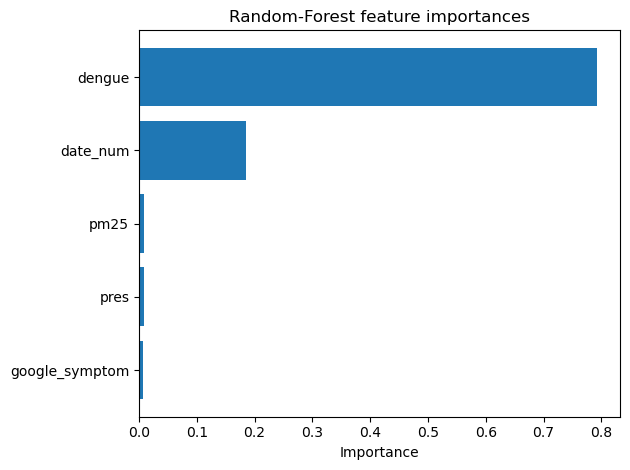

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------------
# 0. Load / tidy data
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1. Keep rows with a non‑missing Dengue target
# -------------------------------------------------------------
TARGET          = 'dengue_1'          #  t‑1 (or whatever your suffix means)
LAGGED_TARGET   = 'dengue'            #  same series, lagged
NON_TARGET_LAGS = ['zika', 'chikungunya', 'varicella', 'zika_1', 'chikungunya_1', 'varicella_1']  # lagged cols to drop

df_d = (
    df.copy()
      .dropna(subset=[TARGET])        # remove rows w/ NaN target
      .sort_values('date')
      .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2. Features / target split
# -------------------------------------------------------------
y = df_d[TARGET]

X = (
    df_d
      .drop(columns=['date', TARGET]) # drop date & **only** Dengue target
      .select_dtypes(include='number')
)

# remove lagged epidemics that are *not* Dengue
X = X.drop(
    columns=[c for c in NON_TARGET_LAGS if c in X.columns],
    errors='ignore'
)

# -------------------------------------------------------------
# 3. Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt   = int(0.8 * len(X))
X_train    = X.iloc[:split_pt]
X_test     = X.iloc[split_pt:]
y_train    = y.iloc[:split_pt]
y_test     = y.iloc[split_pt:]
dates_test = df_d.loc[split_pt:, 'date']

# -------------------------------------------------------------
# 4. Random‑forest hyper‑parameter search (time‑series CV)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [400, 800, 1200],
    "max_depth":        [None, 10, 20],
    "max_features":     ["sqrt", 0.6, 0.8],
    "min_samples_leaf": [1, 3, 5],
    "bootstrap":        [True, False],
}

ts_cv   = TimeSeriesSplit(n_splits=3)
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator   = rf_base,
    param_grid  = param_grid,
    cv          = ts_cv,
    scoring     = "neg_root_mean_squared_error",
    n_jobs      = -1,
    verbose     = 0
)
grid.fit(X_train, y_train)

best_rf   = grid.best_estimator_
best_pars = grid.best_params_
print("⇨ best params:", best_pars)

# -------------------------------------------------------------
# 5. Hold‑out evaluation
# -------------------------------------------------------------
y_pred = best_rf.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
print(f"Test RMSE = {rmse:0.2f}")
print(f"Test  R²  = {r2:0.3f}")




# 6‑B. Feature importances
importances   = best_rf.feature_importances_
idx_sorted    = np.argsort(importances)
plt.barh(X_train.columns[idx_sorted], importances[idx_sorted])
plt.title("Random‑Forest feature importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

## Gradient Boosting

⇨ best params: {'learning_rate': 0.05, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}
Test RMSE = 998.54
Test  R²  = -1.760


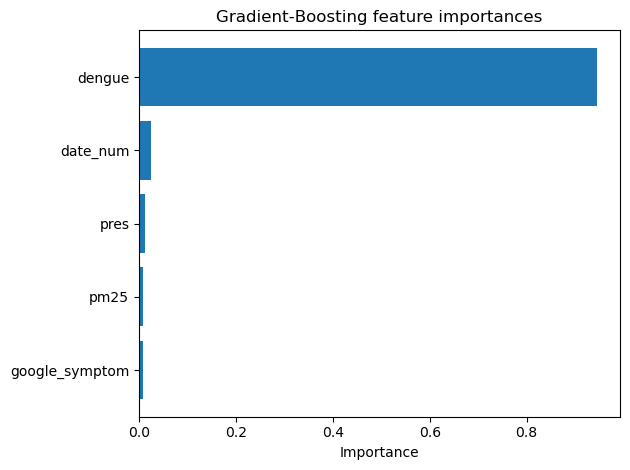

In [24]:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


# -------------------------------------------------------------
# 0. Load / tidy data
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# 1. Keep rows with a non‑missing Dengue target
# -------------------------------------------------------------
TARGET          = 'dengue_1'          # lag‑1 Dengue cases
NON_TARGET_LAGS = [
    'zika', 'chikungunya', 'varicella',
    'zika_1', 'chikungunya_1', 'varicella_1'
]

df_d = (
    df.copy()
      .dropna(subset=[TARGET])
      .sort_values('date')
      .reset_index(drop=True)
)

# -------------------------------------------------------------
# 2. Features / target split  (identical selection as RF script)
# -------------------------------------------------------------
y = df_d[TARGET]

X = (
    df_d
      .drop(columns=['date', TARGET])            # drop date & Dengue target
      .select_dtypes(include='number')           # keep numeric predictors
      .drop(columns=[c for c in NON_TARGET_LAGS if c in df_d.columns],
            errors='ignore')                     # drop other lagged epidemics
)

# -------------------------------------------------------------
# 3. Chronological 80 / 20 split
# -------------------------------------------------------------
split_pt   = int(0.8 * len(X))
X_train    = X.iloc[:split_pt]
X_test     = X.iloc[split_pt:]
y_train    = y.iloc[:split_pt]
y_test     = y.iloc[split_pt:]
dates_test = df_d.loc[split_pt:, 'date']

# -------------------------------------------------------------
# 4. Gradient‑Boosting hyper‑parameter search (time‑series CV)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [200, 400, 800],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.7, 0.9, 1.0],
    "min_samples_leaf": [1, 3, 5],
    "max_features":     ["sqrt", 0.6, None],
}

ts_cv = TimeSeriesSplit(n_splits=3)
gb_base = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator   = gb_base,
    param_grid  = param_grid,
    cv          = ts_cv,
    scoring     = "neg_root_mean_squared_error",
    n_jobs      = -1,
    verbose     = 0,
)
grid.fit(X_train, y_train)

best_gb   = grid.best_estimator_
best_pars = grid.best_params_
print("⇨ best params:", best_pars)

# -------------------------------------------------------------
# 5. Hold‑out evaluation
# -------------------------------------------------------------
y_pred = best_gb.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
print(f"Test RMSE = {rmse:0.2f}")
print(f"Test  R²  = {r2:0.3f}")

# -------------------------------------------------------------
# 6. Quick plots – hold‑out fit & feature importances
# -------------------------------------------------------------



# 6‑B. Feature importances
importances = best_gb.feature_importances_
idx_sorted  = np.argsort(importances)
plt.barh(X_train.columns[idx_sorted], importances[idx_sorted])
plt.title("Gradient‑Boosting feature importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()


## Combined Plot

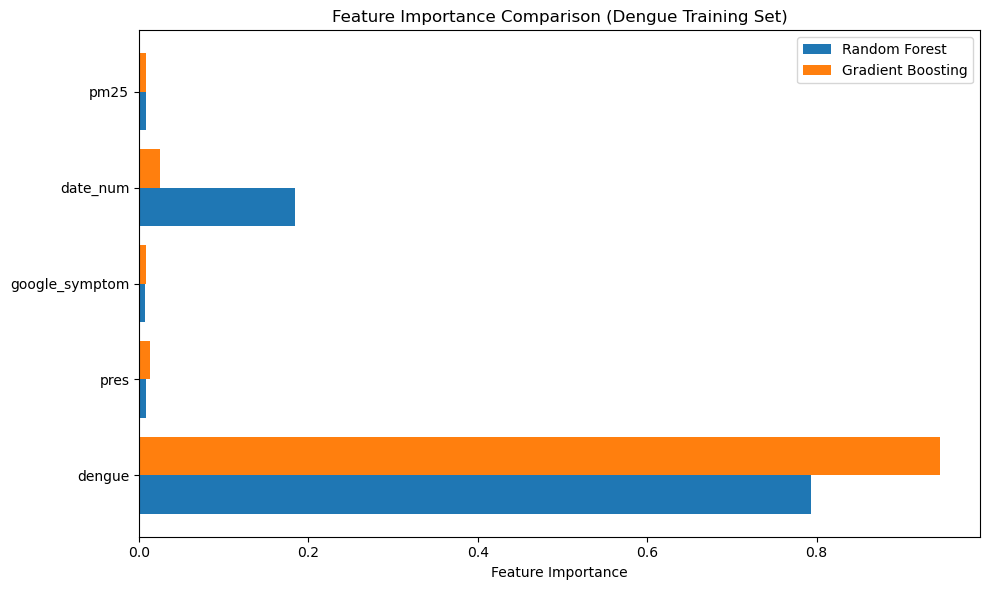

In [25]:
# Extract importances and feature names
importances_rf = best_rf.feature_importances_
importances_gb = best_gb.feature_importances_
feat_names     = X_train.columns.tolist()

# Prepare positions for grouped bars
y_pos = np.arange(len(feat_names))
height = 0.4

fig, ax = plt.subplots(figsize=(10, 6))

# Plot grouped horizontal bars
ax.barh(y_pos - height/2, importances_rf, height=height, label="Random Forest")
ax.barh(y_pos + height/2, importances_gb, height=height, label="Gradient Boosting")

# Labeling
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_names)
ax.set_xlabel("Feature Importance")
ax.set_title("Feature Importance Comparison (Dengue Training Set)")
ax.legend()

plt.tight_layout()
# save to pdf
plt.savefig('../latex_plots/feature_importance_dengue.pdf', bbox_inches='tight')
plt.show()